In [11]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR  = Path('/home/isacco/DATA/ZOU_GPR')
CASES_DIR = DATA_DIR / 'Datasets_Isacco'

COLS = [
    'x','y','z','alphat',
    'C2H','C2H2','C2H3','C2H4','C2H5','C2H6','C3H7','C3H8',
    'CH','CH2','CH2CHO','CH2CO','CH2O','CH2OH','CH2S','CH3','CH3CHO','CH3O','CH3OH',
    'CH4','CO','CO2','epsilon','H','H2','H2O','H2O2','HCCO','HCCOH','HCO','HO2',
    'k','N2','O2','OH','p','T','Ux','Uy','Uz'
]
COLS_IDX = {name: i for i, name in enumerate(COLS)}
IMPORTANT_FIELDS = ['T', 'OH', 'CO2', 'CH4', 'H2O', 'CO']

In [12]:
# Basic file diagnostics
for name in ['Case17_mfH2_0.16_Re_13000.xy', 'Case22_mfH2_0.20_Re_13000.xy']:
    path = CASES_DIR / name
    size_mb = path.stat().st_size / 1e6
    with open(path) as f:
        lines = f.readlines()
    n_data = len(lines) - 1  # subtract header
    col_counts = set(len(l.split()) for l in lines[1:])
    print(f"{name}")
    print(f"  size: {size_mb:.1f} MB  |  data rows: {n_data}  (expected 8484 = 101x84)")
    print(f"  column counts seen in data rows: {col_counts}")
    print()

Case17_mfH2_0.16_Re_13000.xy
  size: 5.5 MB  |  data rows: 8484  (expected 8484 = 101x84)
  column counts seen in data rows: {44}

Case22_mfH2_0.20_Re_13000.xy
  size: 5.5 MB  |  data rows: 8484  (expected 8484 = 101x84)
  column counts seen in data rows: {44}



In [13]:
def load_raw(path):
    """Load keeping only complete 44-column rows, return raw array and coverage info."""
    rows = []
    with open(path) as f:
        next(f)  # skip header
        for line in f:
            vals = line.split()
            if len(vals) == 44:
                rows.append([float(v) for v in vals])
    return np.array(rows)

raw17 = load_raw(CASES_DIR / 'Case17_mfH2_0.16_Re_13000.xy')
raw22 = load_raw(CASES_DIR / 'Case22_mfH2_0.20_Re_13000.xy')

# Reference case (known-good)
raw_ref = load_raw(CASES_DIR / 'Case01_mfH2_0.04_Re_11000.xy')

print(f"Case17 rows loaded: {len(raw17)}")
print(f"Case22 rows loaded: {len(raw22)}")
print(f"Reference rows:     {len(raw_ref)}  (should be 8484)")

Case17 rows loaded: 8484
Case22 rows loaded: 8484
Reference rows:     8484  (should be 8484)


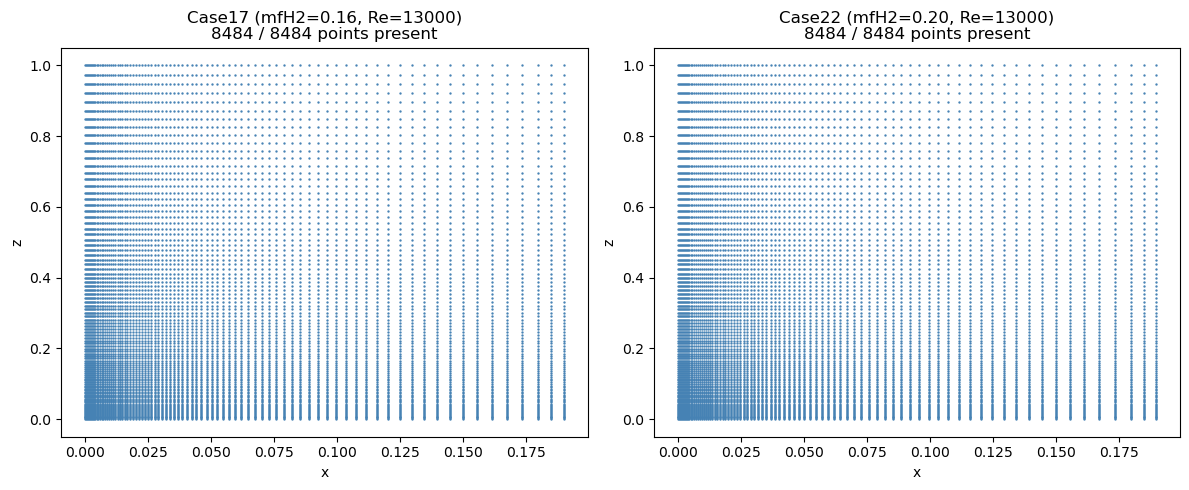

In [14]:
# Show which (x, z) coordinates are present vs missing
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, raw, title in zip(axes, [raw17, raw22], ['Case17 (mfH2=0.16, Re=13000)', 'Case22 (mfH2=0.20, Re=13000)']):
    ax.scatter(raw[:, COLS_IDX['x']], raw[:, COLS_IDX['z']], s=0.5, c='steelblue')
    ax.set_xlabel('x')
    ax.set_ylabel('z')
    ax.set_title(f"{title}\n{len(raw)} / 8484 points present")

plt.tight_layout()
plt.show()

In [15]:
def try_reshape(raw, label):
    """Attempt to build a structured grid from whatever rows are present."""
    x_vals = np.unique(raw[:, COLS_IDX['x']])
    z_vals = np.unique(raw[:, COLS_IDX['z']])
    print(f"{label}: {len(x_vals)} unique x, {len(z_vals)} unique z  "
          f"=> {len(x_vals)*len(z_vals)} expected, {len(raw)} present")
    return x_vals, z_vals

x17, z17 = try_reshape(raw17, 'Case17')
x22, z22 = try_reshape(raw22, 'Case22')

Case17: 84 unique x, 101 unique z  => 8484 expected, 8484 present
Case22: 84 unique x, 101 unique z  => 8484 expected, 8484 present


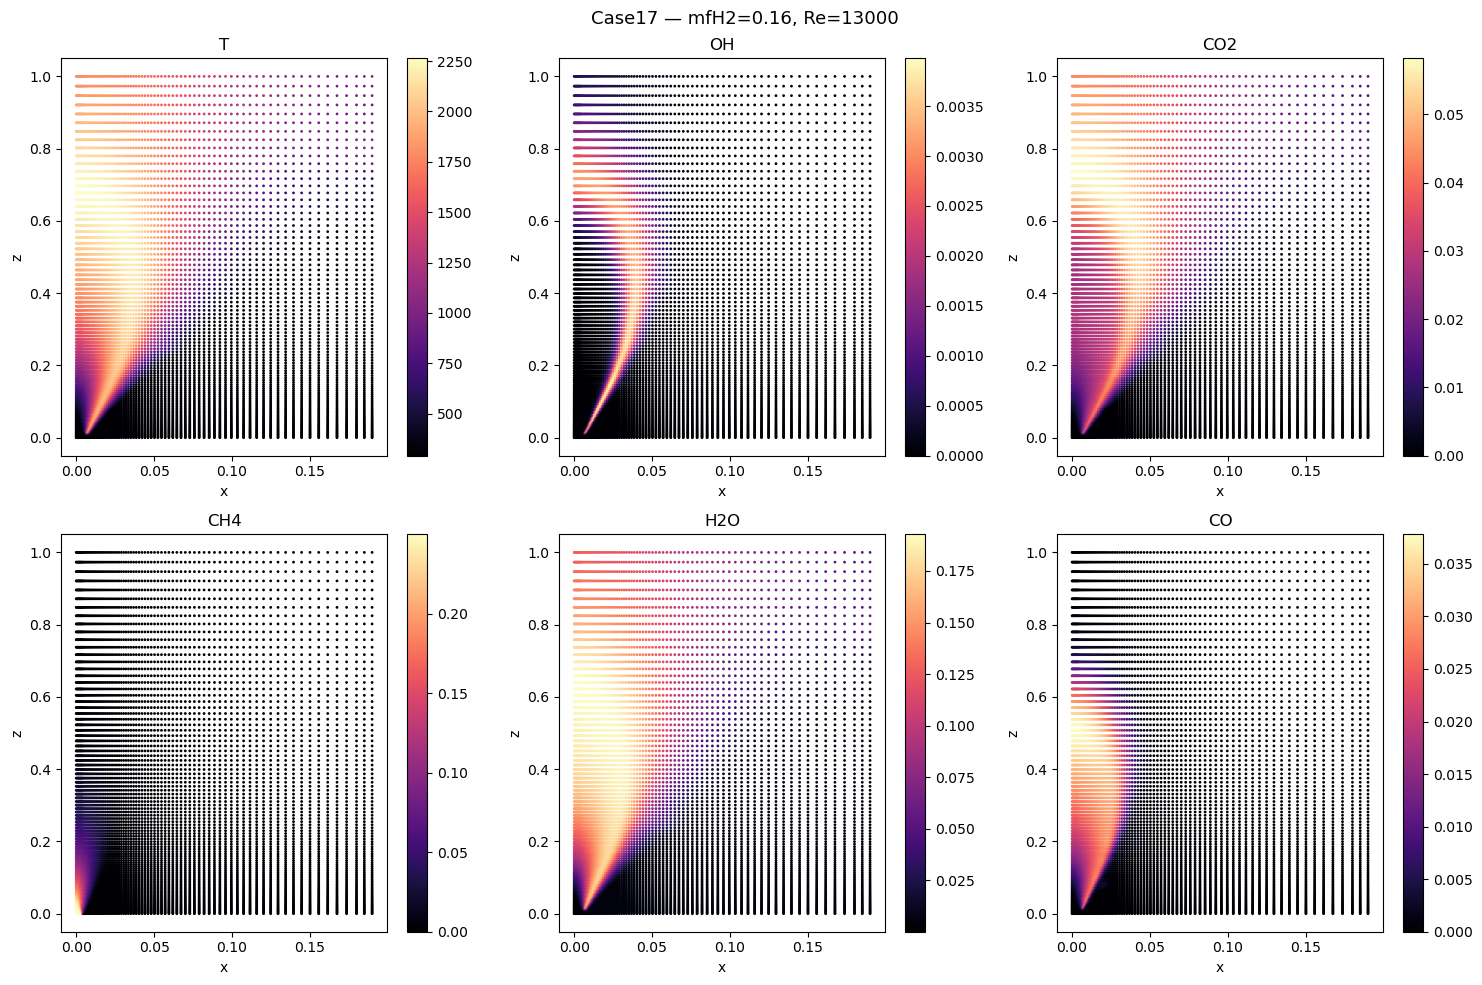

In [16]:
# Plot available fields as scatter (no reshape needed — works even for partial data)
def scatter_fields(raw, title):
    n_cols = 3
    n_rows = (len(IMPORTANT_FIELDS) + n_cols - 1) // n_cols
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    fig.suptitle(title, fontsize=13)
    axs = axs.flatten()
    x = raw[:, COLS_IDX['x']]
    z = raw[:, COLS_IDX['z']]
    for i, field in enumerate(IMPORTANT_FIELDS):
        vals = raw[:, COLS_IDX[field]]
        sc = axs[i].scatter(x, z, c=vals, s=1, cmap='magma')
        plt.colorbar(sc, ax=axs[i])
        axs[i].set_title(field)
        axs[i].set_xlabel('x')
        axs[i].set_ylabel('z')
    for j in range(len(IMPORTANT_FIELDS), len(axs)):
        axs[j].axis('off')
    plt.tight_layout()
    plt.show()

scatter_fields(raw17, 'Case17 — mfH2=0.16, Re=13000')

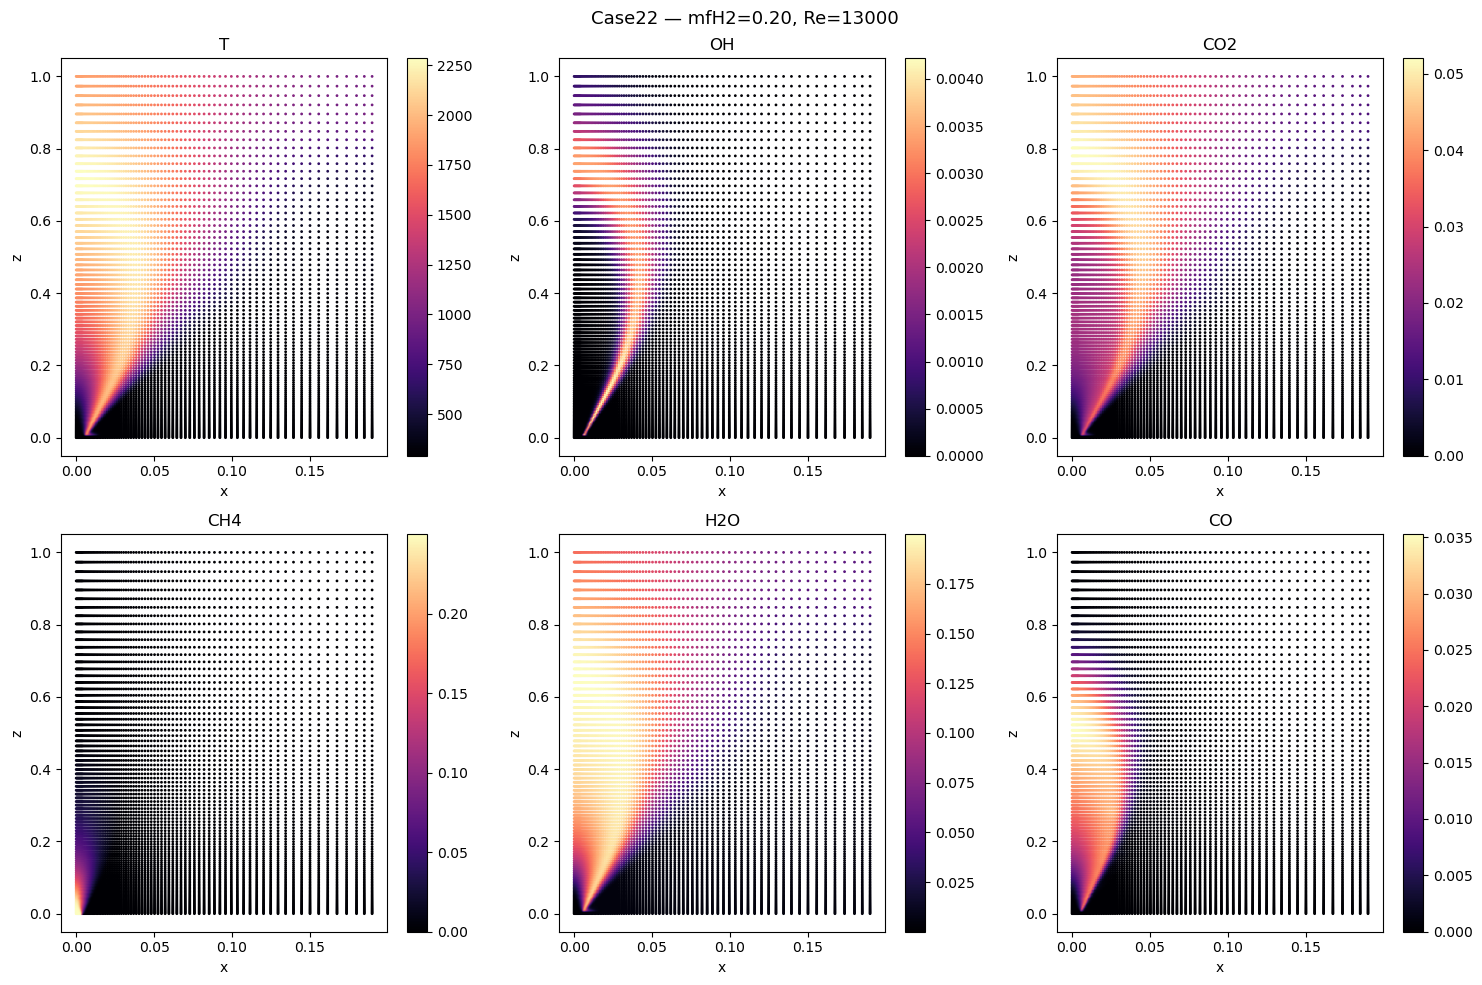

In [17]:
scatter_fields(raw22, 'Case22 — mfH2=0.20, Re=13000')

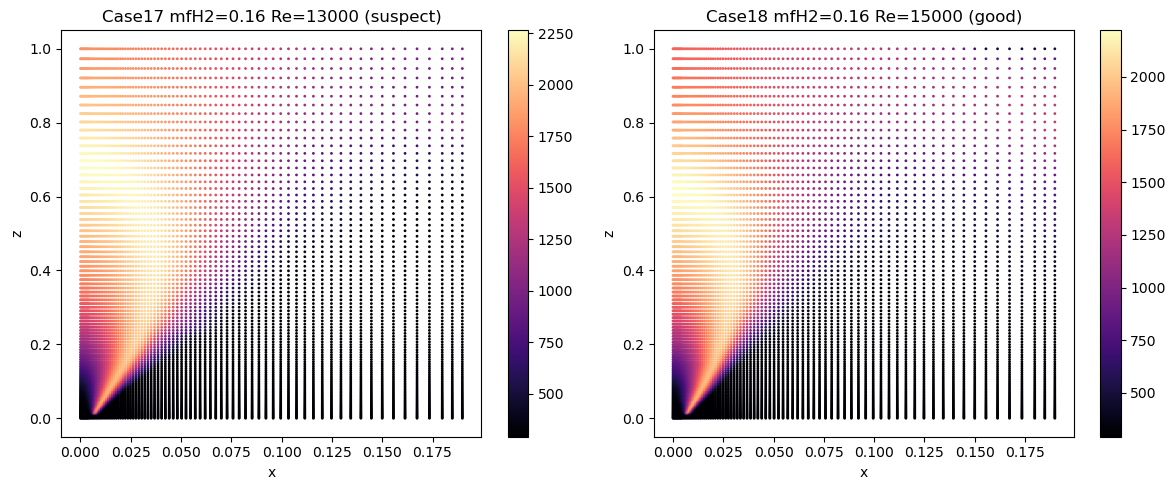

In [18]:
# Side-by-side T field: Case17 vs a good neighbour (Case18: mfH2=0.16, Re=15000)
raw18 = load_raw(CASES_DIR / 'Case18_mfH2_0.16_Re_15000.xy')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, raw, title in zip(axes,
                           [raw17, raw18],
                           ['Case17 mfH2=0.16 Re=13000 (suspect)', 'Case18 mfH2=0.16 Re=15000 (good)']):
    sc = ax.scatter(raw[:, COLS_IDX['x']], raw[:, COLS_IDX['z']],
                    c=raw[:, COLS_IDX['T']], s=1, cmap='magma')
    plt.colorbar(sc, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('z')

plt.tight_layout()
plt.show()

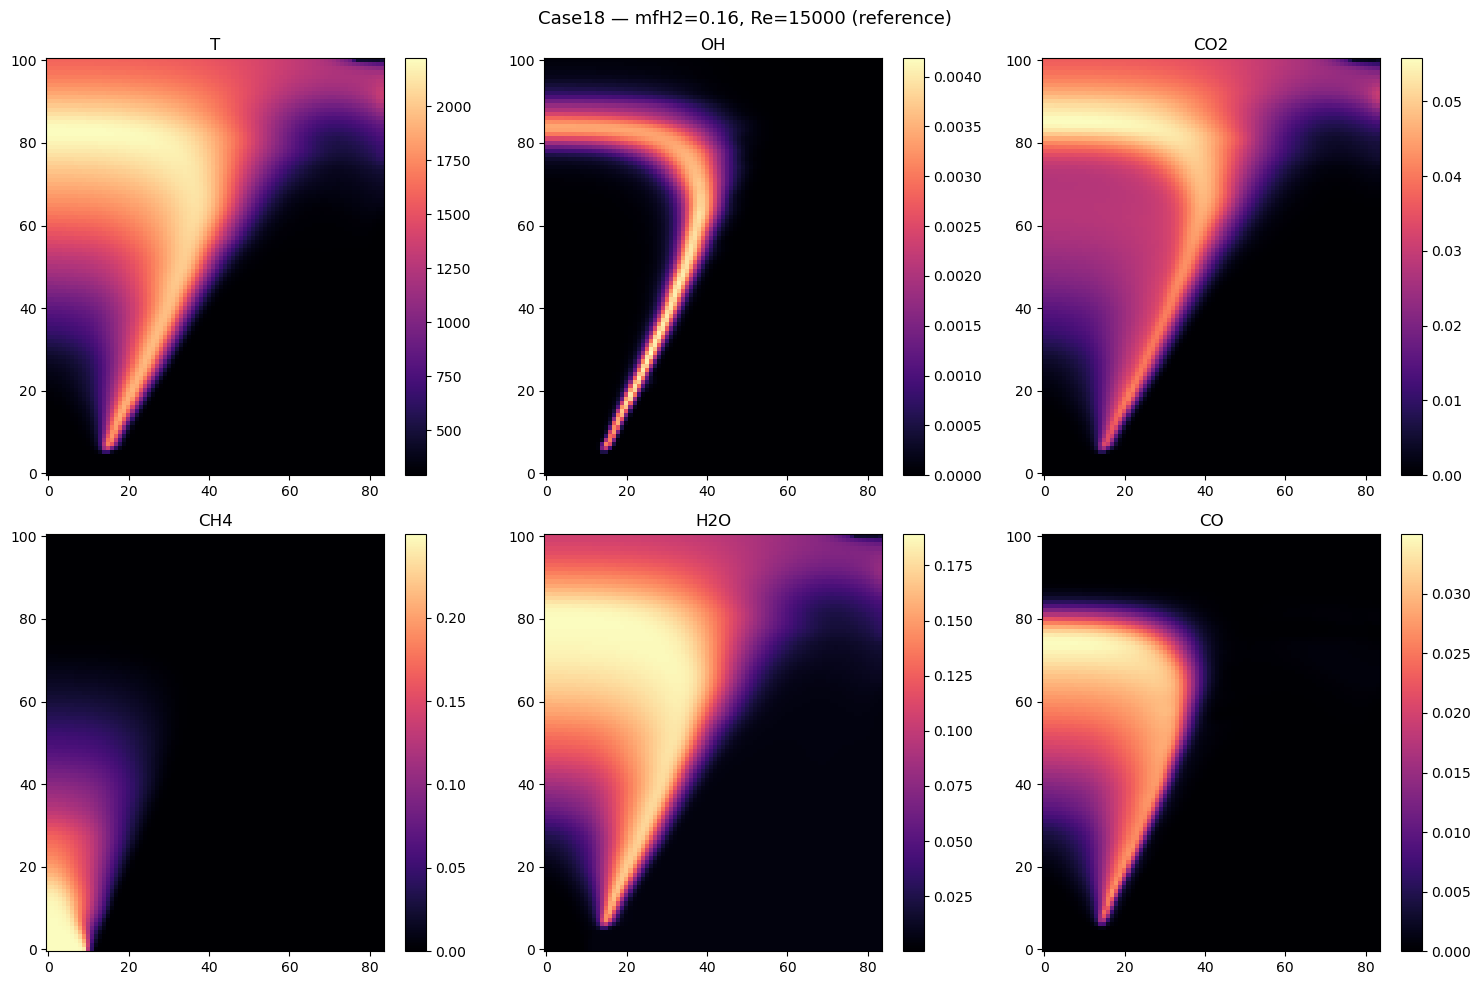

In [19]:
def to_grid(raw):
    """Reshape raw rows into (Nz, Nx, 44). Requires a complete, regular grid."""
    x_vals = np.unique(raw[:, COLS_IDX['x']])
    z_vals = np.unique(raw[:, COLS_IDX['z']])
    idx = np.lexsort((raw[:, COLS_IDX['x']], raw[:, COLS_IDX['z']]))
    return raw[idx].reshape(len(z_vals), len(x_vals), 44)

def imshow_fields(raw, title):
    grid = to_grid(raw)
    n_cols = 3
    n_rows = (len(IMPORTANT_FIELDS) + n_cols - 1) // n_cols
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    fig.suptitle(title, fontsize=13)
    axs = axs.flatten()
    for i, field in enumerate(IMPORTANT_FIELDS):
        im = axs[i].imshow(grid[:, :, COLS_IDX[field]], origin='lower', aspect='auto', cmap='magma')
        plt.colorbar(im, ax=axs[i])
        axs[i].set_title(field)
    for j in range(len(IMPORTANT_FIELDS), len(axs)):
        axs[j].axis('off')
    plt.tight_layout()
    plt.show()

# Use Case18 (known-good, same mfH2 as Case17) as reference
imshow_fields(raw18, 'Case18 — mfH2=0.16, Re=15000 (reference)')

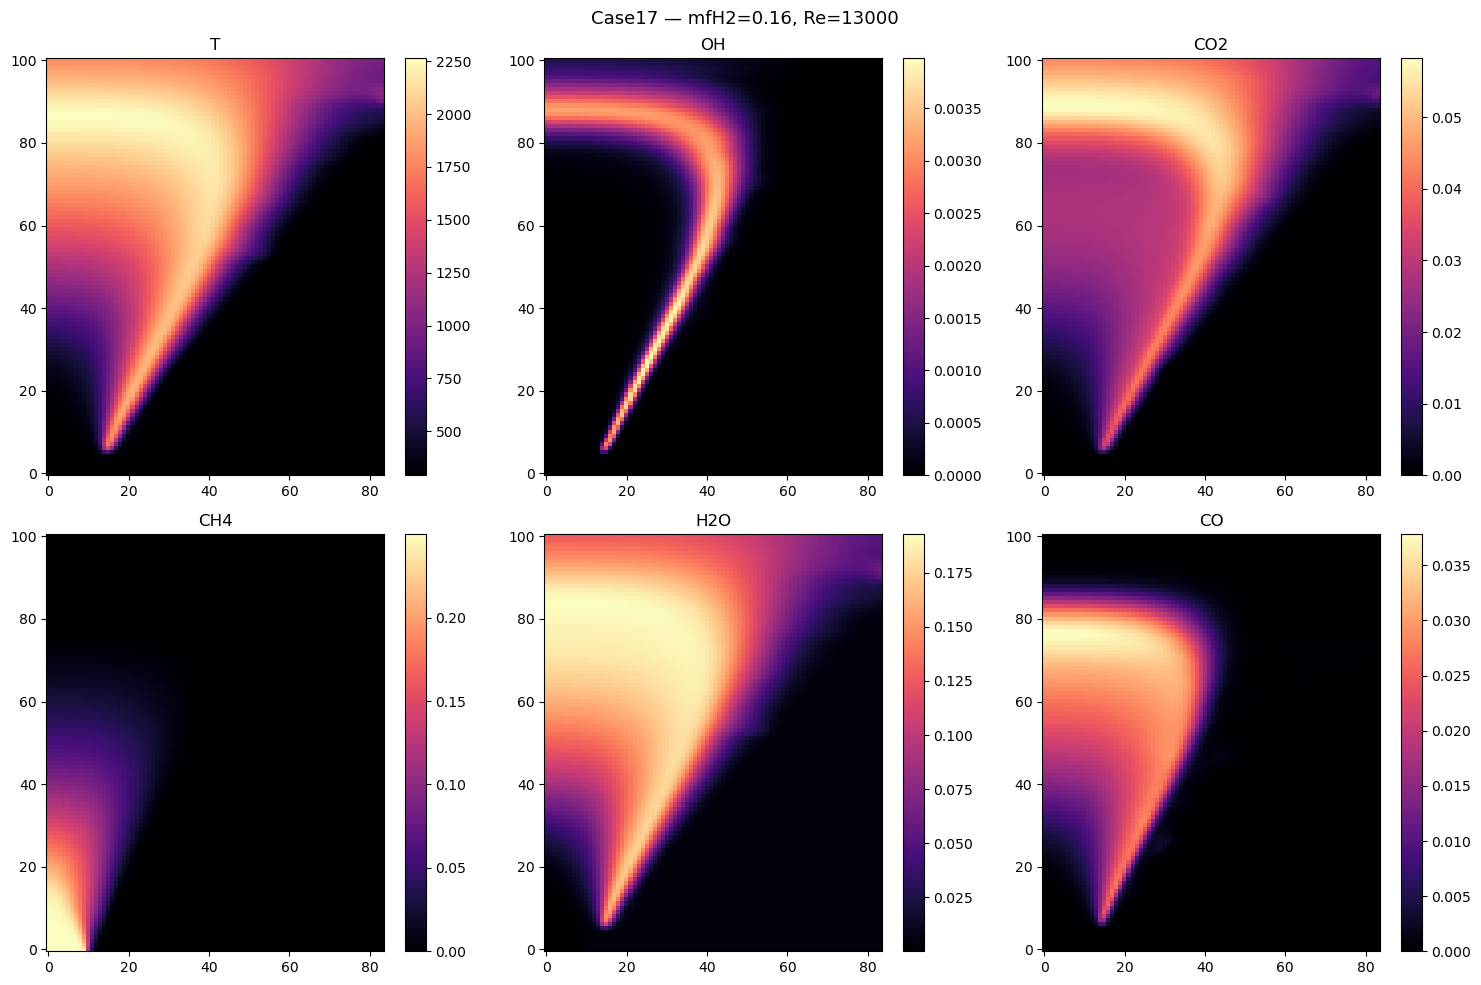

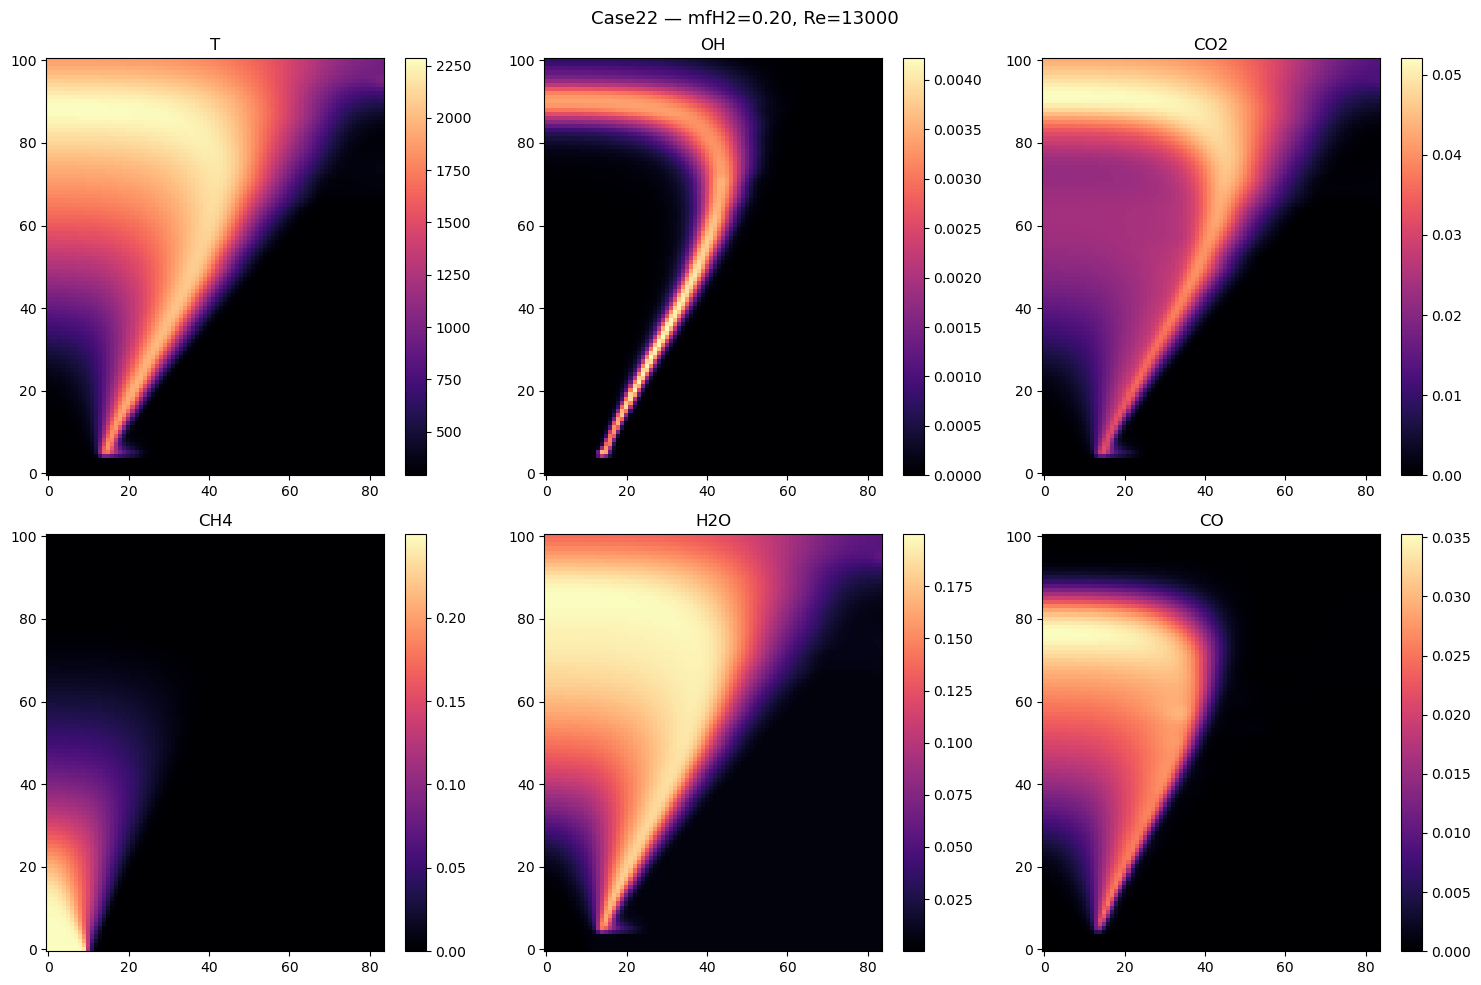

In [20]:
# imshow for Case17 and Case22 — will raise if the grid is not complete/regular
for raw, title in [(raw17, 'Case17 — mfH2=0.16, Re=13000'),
                   (raw22, 'Case22 — mfH2=0.20, Re=13000')]:
    try:
        imshow_fields(raw, title)
    except Exception as e:
        print(f"{title}: cannot imshow — {e}")